In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Replaced the blank values with 0, as the tenure is 0 and no total charges were recorded and also changed the data type.


In [97]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [98]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [99]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [100]:
df["customerID"].duplicated().sum()

np.int64(0)

### Converted the SeniorCitizen column values from 0 and 1 to Yes and No to make the data easier to understand.


In [101]:
def convert(value) :
    if value == 1 :
        return "yes"
    else:
        return "no"

df["SeniorCitizen"]= df["SeniorCitizen"].apply(convert)
df 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,no,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,no,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,no,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


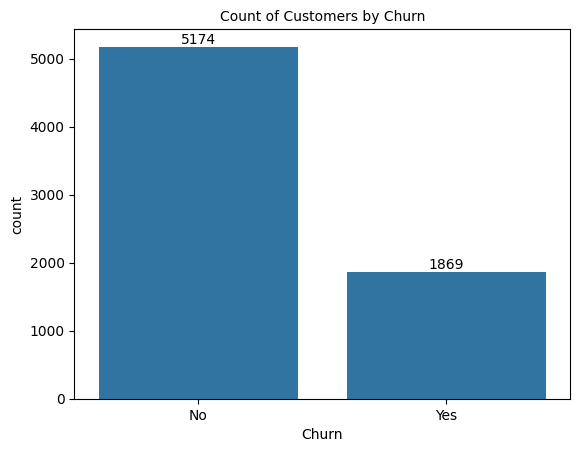

In [146]:
ax =sns.countplot(x=df["Churn"])

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn" , fontsize = 10)

plt.show()

In [103]:
gb = df.groupby("Churn").agg({"Churn": "count"})
gb

,Churn
Churn,
No,5174
Yes,1869


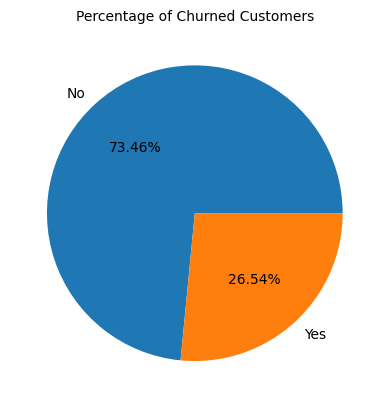

In [113]:
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f%%")

plt.title("Percentage of Churned Customers", fontsize = 10)

plt.show()

### From the given pie chart, we can conclude that 26.54% of the customers have churned, while the remaining 73.46% have continued with the service.


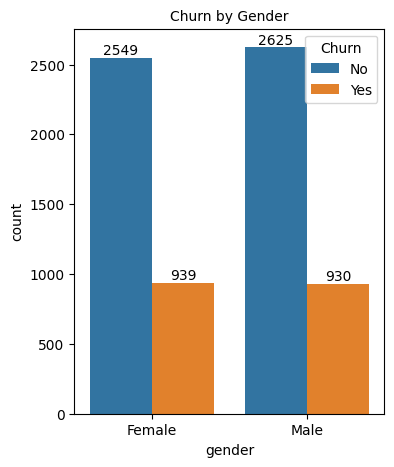

In [141]:
plt.figure(figsize=(4,5))

ax = sns.countplot(x=df["gender"], hue=df["Churn"])
plt.title("Churn by Gender", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

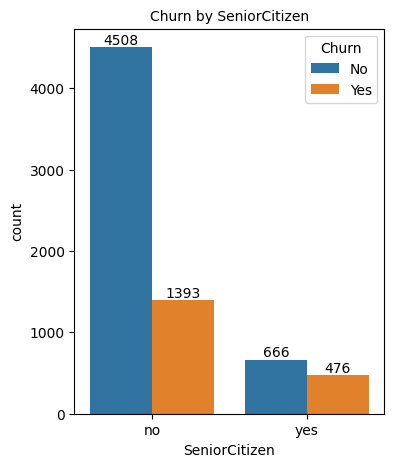

In [140]:
plt.figure(figsize=(4,5))

ax = sns.countplot(x=df["SeniorCitizen"], hue=df["Churn"])
plt.title("Churn by SeniorCitizen", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

### Senior Citizen Churn Analysis
From the above graph, we can conclude that **senior citizens have a higher churn rate compared to non-senior citizens.**


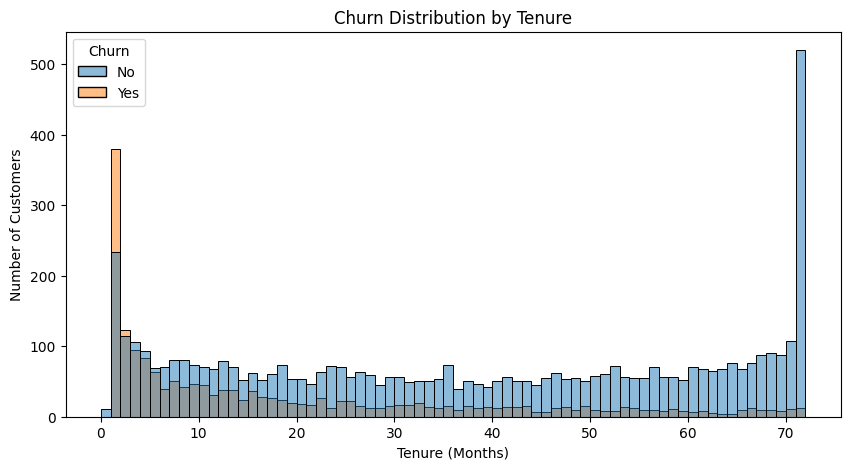

In [135]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df,x="tenure",bins=72,hue="Churn")

plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Churn by Tenure

From the above graph, we can conclude that **people who have used our services for a longer time tend to stay, while people who have used our services for only 1–2 months are more likely to leave.**


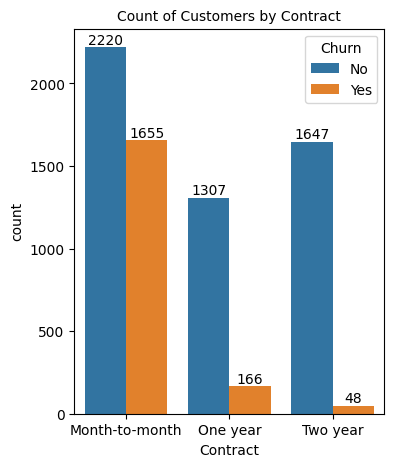

In [160]:
plt.figure(figsize=(4,5))

ax = sns.countplot(x=df["Contract"], hue=df["Churn"])
plt.title("Count of Customers by Contract", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

### Churn by Contract Type

People with a **month-to-month contract are more likely to churn** than those with **1-year or 2-year contracts**.


In [152]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

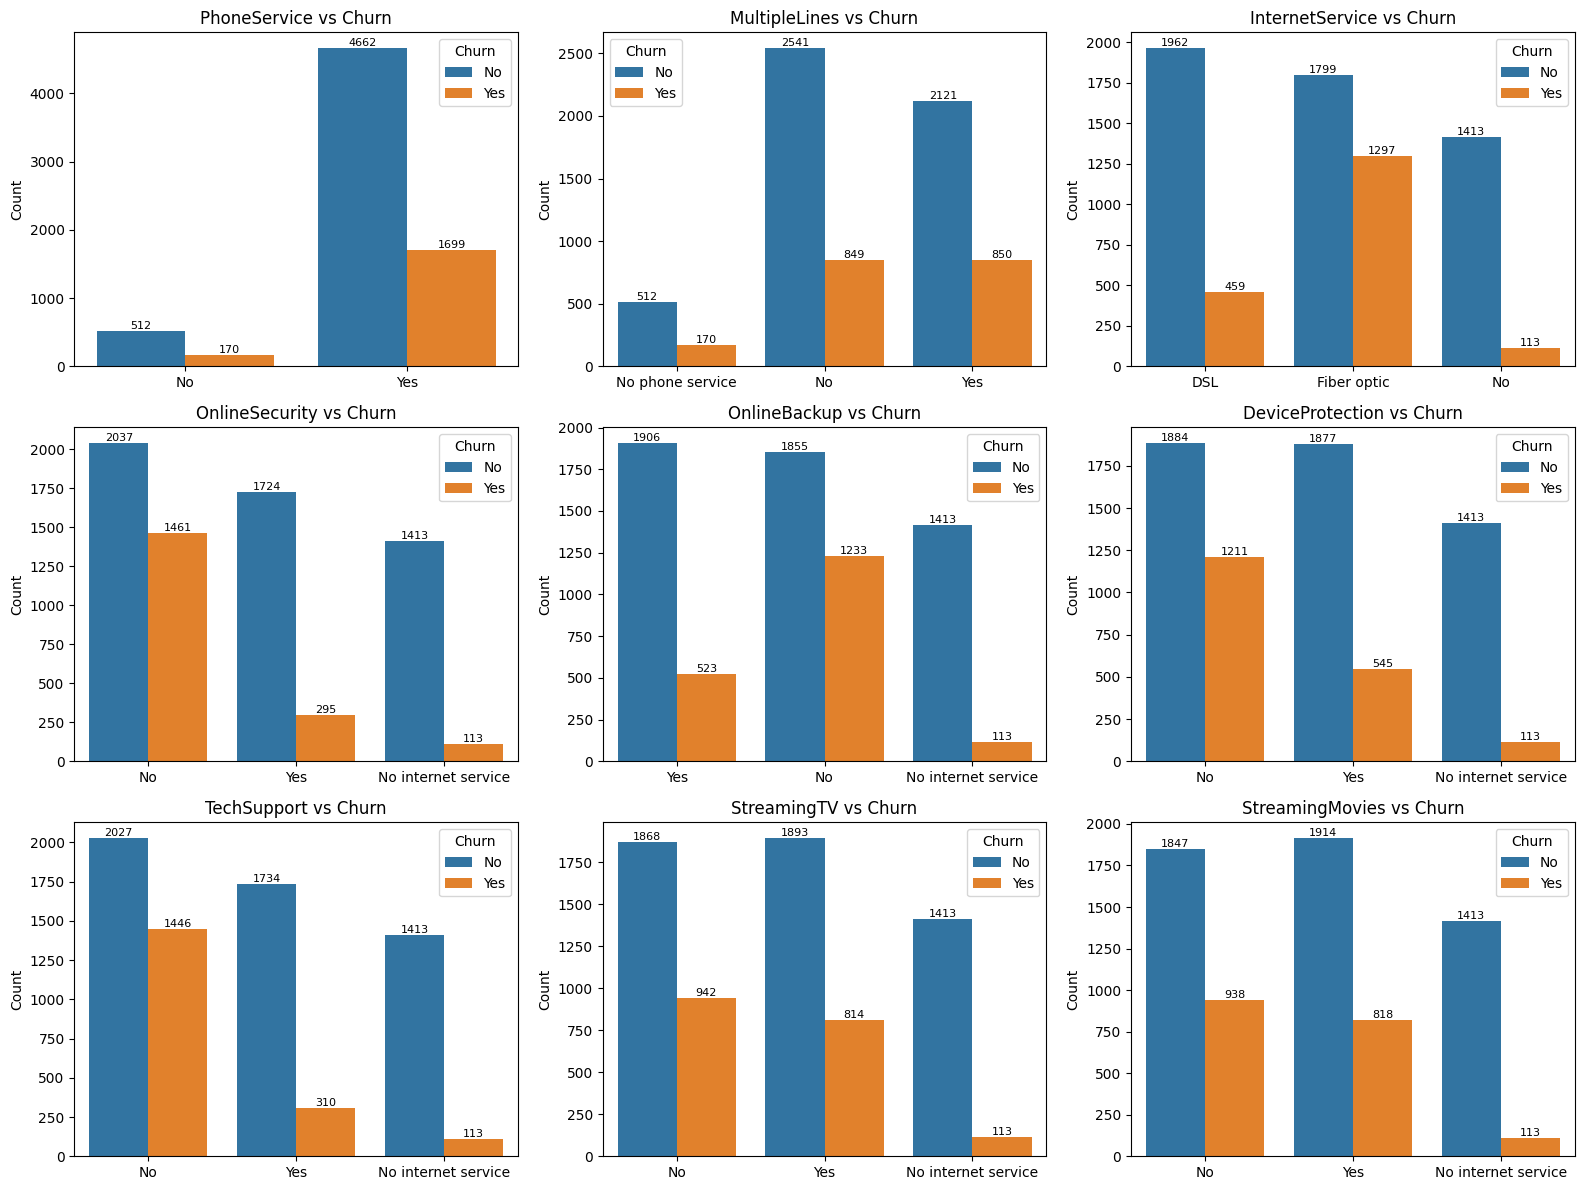

In [159]:
columns = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flat, columns):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=0)

# Show values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=8)

plt.tight_layout()
plt.show()

### Summary

1. Customers with **Fiber optic internet service** show a relatively higher level of churn compared to DSL users.
2. Customers **without Online Security, Online Backup, Device Protection, and Tech Support** are more likely to churn.
3. Customers with **Streaming TV and Streaming Movies** also show noticeable churn.
4. Overall, customers who use **additional services** tend to have lower churn compared to those who do not.

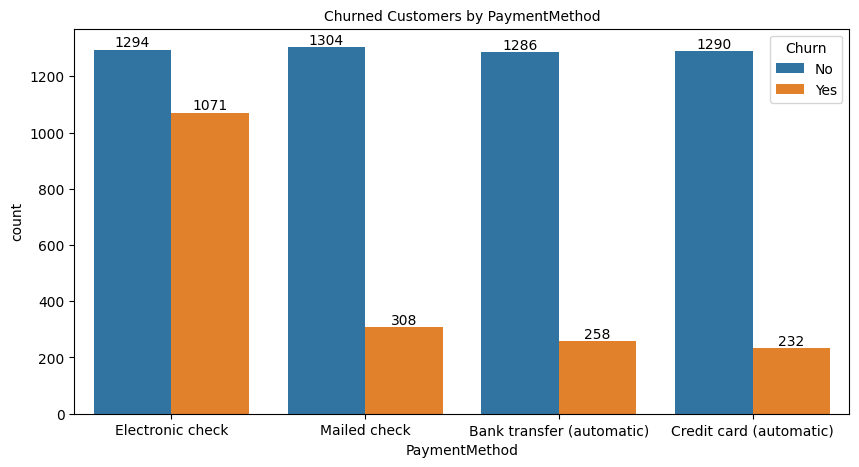

In [172]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x=df["PaymentMethod"], hue=df["Churn"])
plt.title("Churned Customers by PaymentMethod", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.show()

### Churn by Payment Method

Customers are **more likely to churn when they use Electronic Check as their payment method**.